Customer Personality Analysis: Marketing Campaign Report

In [ ]:
# Install package
install.packages("tidyverse")
install.packages("dplyr")
install.packages("broom")

In [ ]:
# Libraries used
library(tidyverse)
library(dplyr)
library(broom)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.1     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
#Dataset taken from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?resource=download 

cpa <- read.delim("marketing_campaign.csv")

# (1) Data Description

(a) 2,240 rows of observations and 29 variables

In [4]:
# Number of observations & variables
glimpse(cpa)

Rows: 2,240
Columns: 29
$ ID                  <int> 5524, 2174, 4141, 6182, 5324, 7446, 965, 6177, 485…
$ Year_Birth          <int> 1957, 1954, 1965, 1984, 1981, 1967, 1971, 1985, 19…
$ Education           <chr> "Graduation", "Graduation", "Graduation", "Graduat…
$ Marital_Status      <chr> "Single", "Single", "Together", "Together", "Marri…
$ Income              <int> 58138, 46344, 71613, 26646, 58293, 62513, 55635, 3…
$ Kidhome             <int> 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1,…
$ Teenhome            <int> 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1,…
$ Dt_Customer         <chr> "04-09-2012", "08-03-2014", "21-08-2013", "10-02-2…
$ Recency             <int> 58, 38, 26, 26, 94, 16, 34, 32, 19, 68, 11, 59, 82…
$ MntWines            <int> 635, 11, 426, 11, 173, 520, 235, 76, 14, 28, 5, 6,…
$ MntFruits           <int> 88, 1, 49, 4, 43, 42, 65, 10, 0, 0, 5, 16, 61, 2, …
$ MntMeatProducts     <int> 546, 6, 127, 20, 118, 98, 164, 56, 24, 6, 6, 11, 4…
$ MntFishProduct

(b) Run code below for table:

In [5]:
#Table
data.frame(Type = sapply(cpa, class))

,Type
,<chr>
ID,integer
Year_Birth,integer
Education,character
Marital_Status,character
Income,integer
Kidhome,integer
Teenhome,integer
Dt_Customer,character
Recency,integer



(c) It can be assumed that the data is collected from surveys and data provided by membership subscription.

(d) Dataset is provided by Dr. Omar Romero-Hernandez. Not much else is known.
 

# (2) Question

(a) Do demographics and family structure influence the total spending on wine products?

(b) We focus on both inference and prediction. From an inference perspective, the question helps identify which demographic characteristics, such as income, education, and marital status, are significantly associated with wine spending and how strong those relationships are. From a prediction perspective, we may estimate how much a customer is likely to buy more wine products based on their demographic characteristics and family structure. This can help companies identify customer groups that are more likely to generate higher wine sales.

(c) The response variable is "MntWines". This variable measures the amount of wine purchases by a customer.

(d) The covariates expected to be most important include:

    - Income: is likely strongly associated with more purchasing power.

(e) Other variables will be used as control variables to account for demographic and household differences.

    - Education and Marital Status: These variables may reflect socioeconomic and lifestyle differences that influence spending behaviour.

# (3) Exploratory Data Analysis and Visualization

(a) Dataset loading

In [3]:
# Dataset taken from https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis?resource=download 

cpa <- read.delim("marketing_campaign.csv")

(b) Data cleaning and wrangling

Income and MntWines are log transformed due to skewness in the distribution.

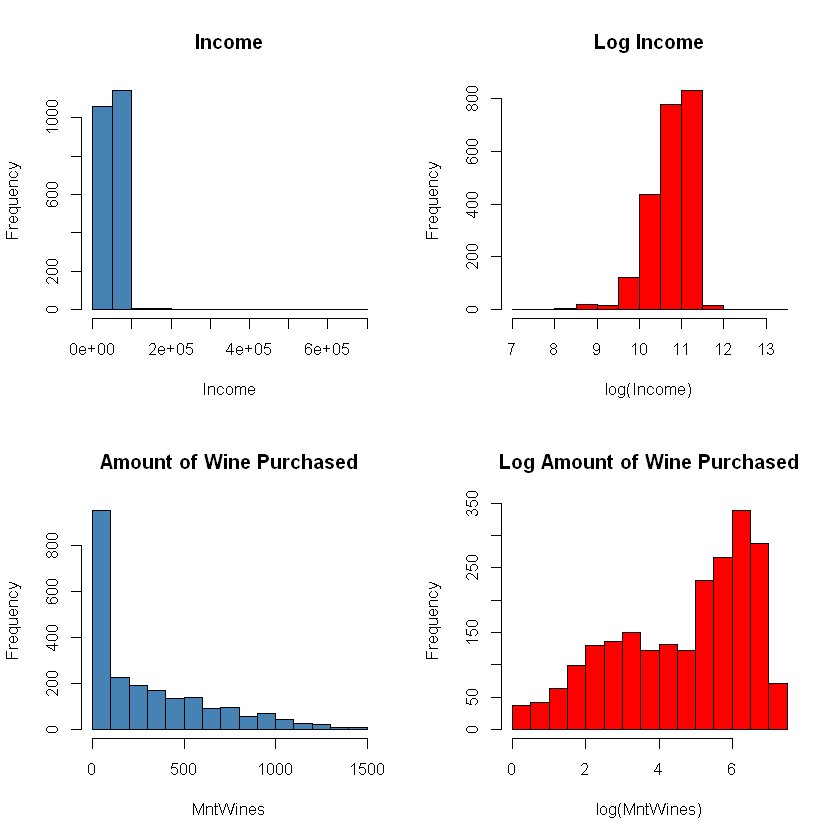

In [48]:
# Skewness
par(mfrow = c(2,2))

hist(cpa$Income,
     main = "Income",
     xlab = "Income",
     col = "steelblue")

hist(log(cpa$Income),
     main = "Log Income",
     xlab = "log(Income)",
     col = "red")

hist(cpa$MntWines,
     main = "Amount of Wine Purchased",
     xlab = "MntWines",
     col = "steelblue")

hist(log(cpa$MntWines),
     main = "Log Amount of Wine Purchased",
     xlab = "log(MntWines)",
     col = "red")

par(mfrow = c(1,1))

In [67]:
# Cleaning and Wrangling
cpa_cleaned <- cpa |> 
    filter(
        !is.na(Income)
        ) |>
    mutate(
        Age = 2026 - Year_Birth,
        Education = as.factor(Education),
        Marital_Status = as.factor(Marital_Status),
        logIncome = log(Income),
        logMntWines = log(MntWines + 1) #Since some customers don't buy wines at all (log(0) is undefined)
    ) |>
select(Age, Education, Marital_Status, logIncome, logMntWines)
head(cpa_cleaned)

,Age,Education,Marital_Status,logIncome,logMntWines
,<dbl>,<fct>,<fct>,<dbl>,<dbl>
1,69,Graduation,Single,10.97057,6.455199
2,72,Graduation,Single,10.74385,2.484907
3,61,Graduation,Together,11.17903,6.056784
4,42,Graduation,Together,10.19039,2.484907
5,45,PhD,Married,10.97324,5.159055
6,59,Master,Together,11.04313,6.255750


(c) There are 24 missing values from Income, with the proportion being less than 0.011. So, there are no variables with a large amount of missing data.

In [77]:
# Missing values
missing_values <- colSums(is.na(cpa))

# Missing proportions
missing_prop <- colMeans(is.na(cpa))

# Missing data table
data.frame(missing_values, missing_prop)

,missing_values,missing_prop
,<dbl>,<dbl>
ID,0,0.00000000
Year_Birth,0,0.00000000
Education,0,0.00000000
Marital_Status,0,0.00000000
Income,24,0.01071429
Kidhome,0,0.00000000
Teenhome,0,0.00000000
Dt_Customer,0,0.00000000
Recency,0,0.00000000


(d) There is no severe class imbalance among the main categories in the dataset, though some minor imbalance exists. In Education, the largest group is Graduation, which represents about 50.3% of customers, while the rest are distributed across PhD (21.7%), Master (16.5%), 2n Cycle (9.1%), and Basic (2.4%).

For Marital_Status, the largest group is Married with approximately 38.6% of customers, with the rest distributed across Together (25.9%), Single (21.4%), Divorced (10.4%) and Widow (3.4%). However, groups like Absurd and YOLO contain extremely few observations, displaying minor imbalance in those rarer groups. 

Overall, the dataset does not exhibit severe class imbalance among the primary categories.

In [75]:
# Class Imbalance Check
cpa_cleaned |> count(Marital_Status) |> mutate(percentage = n / sum(n) * 100) 
cpa_cleaned |> count(Education) |> mutate(percentage = n / sum(n) * 100) 


Marital_Status,n,percentage
<fct>,<int>,<dbl>
Absurd,2,0.09025271
Alone,3,0.13537906
Divorced,232,10.46931408
Married,857,38.67328520
Single,471,21.25451264
Together,573,25.85740072
Widow,76,3.42960289
YOLO,2,0.09025271


Education,n,percentage
<fct>,<int>,<dbl>
2n Cycle,200,9.025271
Basic,54,2.436823
Graduation,1116,50.361011
Master,365,16.471119
PhD,481,21.705776


(e) To explore whether demographics and family structure influence wine spending, I created a faceted scatter plot showing the relationship between income and the number of wine purchases. Both income and wine purchases are log-transformed to reduce skewness and make patterns easier to see. Each point represents a customer, with colors indicating marital status and separate panels representing different education levels.

The plot helps in examining whether customers with higher incomes tend to purchase more wine and whether this relationship differs across demographic groups. The regression lines suggest a positive relationship between income and wine spending. Faceting by education allows us to compare this pattern across education levels, while the color coding highlights potential differences between marital status groups.

`geom_smooth()` using formula = 'y ~ x'


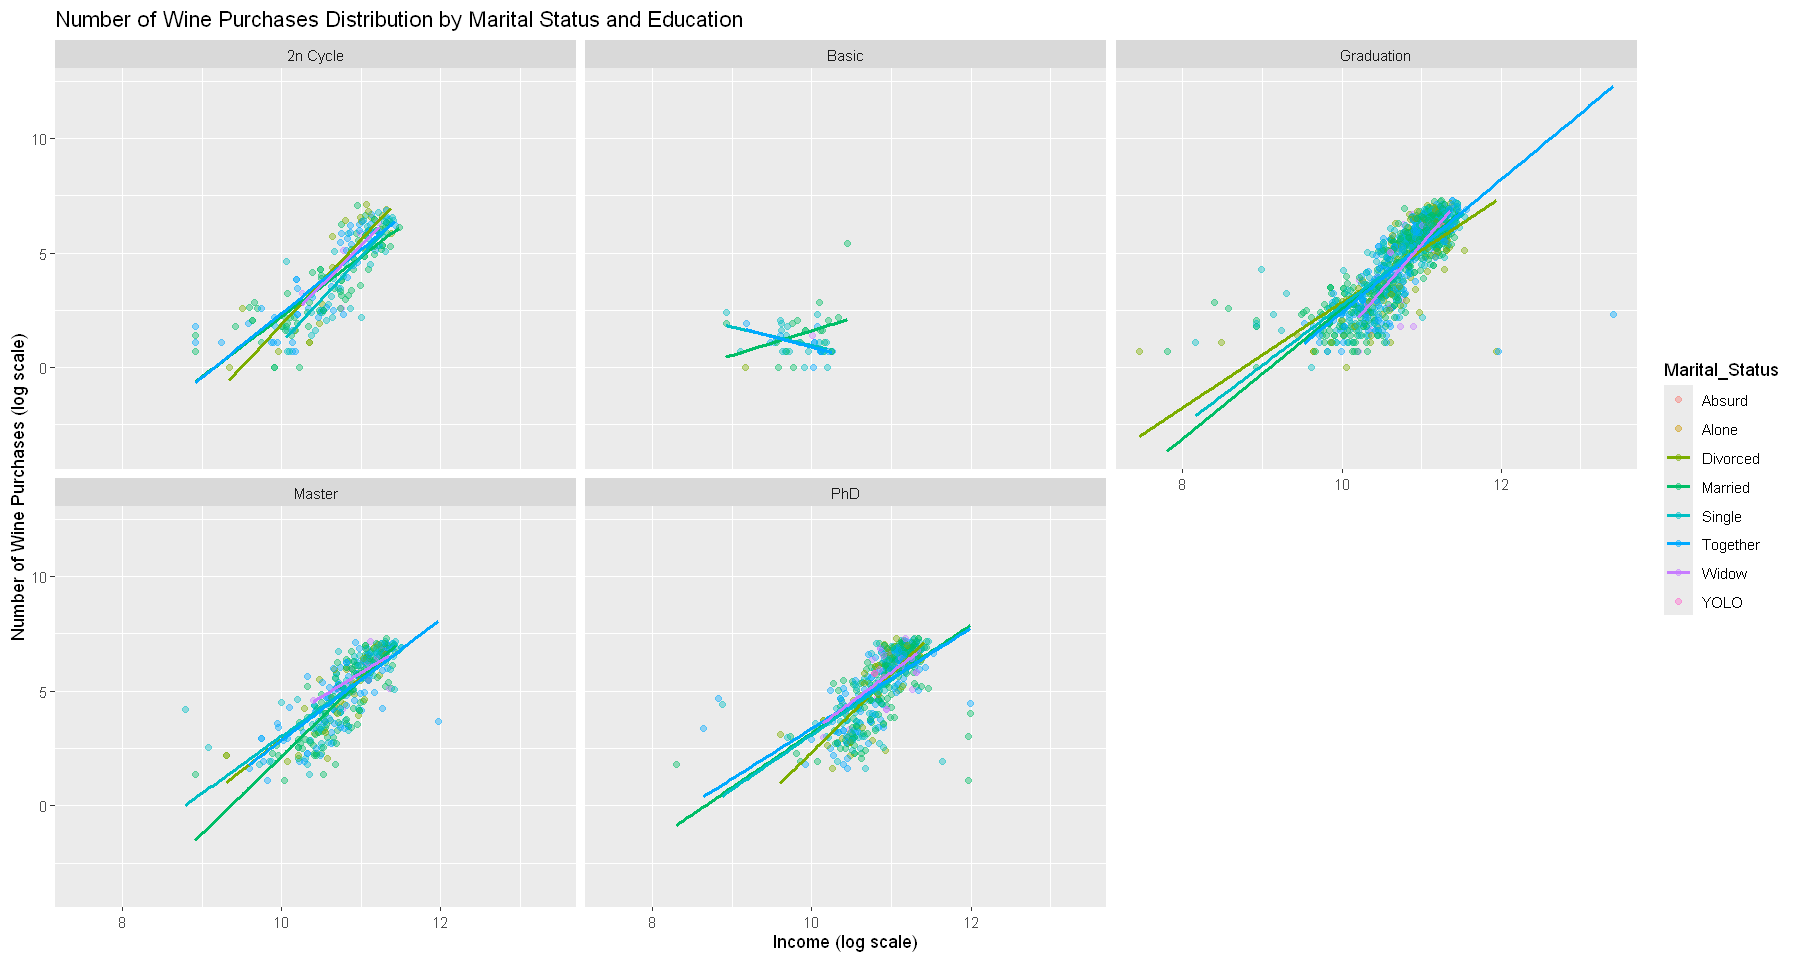

In [78]:
# Adjust accordingly
options(repr.plot.width = 15, repr.plot.height = 8)

# EDA Plot
cpa_cleaned |> 
 ggplot(aes(x = logIncome, y = logMntWines, color = Marital_Status)) +
  geom_point(alpha = 0.4) +
  geom_smooth(method = "lm", se = FALSE) +
  facet_wrap(~Education) +
  labs(
    title = "Number of Wine Purchases Distribution by Marital Status and Education",
    x = "Income (log scale)",
    y = "Number of Wine Purchases (log scale)"
  )

(f) AI is used to refine my sentences and grammar. All analysis and code were implemented and verified by myself, with ideas from worksheets and tutorials.